PHASE 3 PROJECT

> **Personal Context:** I am currently engaged with a Telecom Company 
> in the Customer Service Department, and this informed my problem statement.

# 1. BUSINESS UNDERSTANDING



## 1.1 Project Overview

**STAKEHOLDERS:**
- SyriaTel Churn Risk Management Team
- SyriaTel Customer Retention and Marketing Team

## 1.2 Business Problem

SyriaTel is losing revenue as customers move to competitors. Losing a customer costs more than retaining an existing or gaining a new one.
We want to identify customers likely to churn so that we can target them with retention offers and incentives.

## 1.3 Business Objective

To build a predictive classification model to identify customers likely to churn. This will allow the retention team to intervene with targeted loyalty offers.

# 1.4 Success Metric

Recall -We want to focus on catching actual churners than avoiding a false alarm. A missed churner (False Negative)is more costly than a false alarm (False Positive)

# 2. DATA UNDERSTANDING

## 2.1 Data Loading and Reading

In [48]:
#Importing Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    recall_score
)
print("All imports successful!")

#Data Loading
df = pd.read_csv('churn.csv')

#checking the columns to determine target variable
df.head()

All imports successful!


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [49]:
#Understanding the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [50]:
#checking the stats
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [51]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

Missing values per column:
No missing values found!


## 2.2 Exploratory Data Analysis (EDA)

In [52]:
# checking target variable 
print(df['churn'].value_counts())

False    2850
True      483
Name: churn, dtype: int64


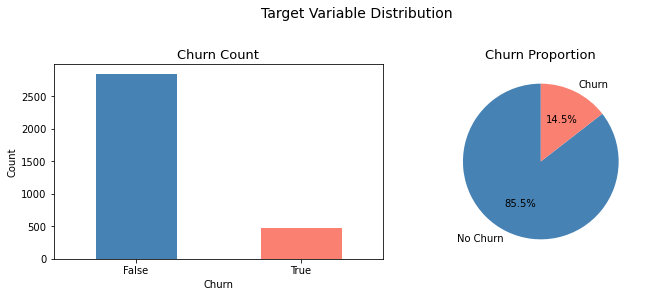

False    85.5
True     14.5
Name: churn, dtype: float64


In [53]:
# Target variable distribution
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Churn Count', fontsize=13)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

axes[1].pie(churn_counts, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'],
            startangle=90)
axes[1].set_title('Churn Proportion', fontsize=13)

plt.suptitle('Target Variable Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(churn_pct.round(1))

**Insight:** The target variable is imbalanced, with approximately 85.5% of customers not churning and only 14.5% churning.


 **False Negative Risk:** If the model says that the customer won't churn (False) but actually does(True),the company loses revenue and has to spend to acquire a new one.
but it completely fails to identify actual churners, which is the business goal.


**Business Implication:**: The model guesses everyone will stay but it completely fails to identify actual churners. We must prioritize **Recall** as our metric to minimize missed churners.


## 3. Data Preparation and Preprocessing

To clean and prepare the data for machine learning, we must:
- Remove identifier columns (phone number, area code, state)
- Encode binary columns (yes/no → 1/0)
- Handle categorical variables (one-hot encoding)
- Split data into train/test sets
- Scale numerical features


In [54]:
# --- Step 1: Encode boolean columns ---
df_clean = df.copy()

# Encode boolean/yes-no columns
bool_cols = df_clean.select_dtypes(include='bool').columns.tolist()
for col in bool_cols:
    df_clean[col] = df_clean[col].astype(int)

# Encode target: True/False or Yes/No -> 1/0
if df_clean['churn'].dtype == 'bool':
    df_clean['churn'] = df_clean['churn'].astype(int)
elif df_clean['churn'].dtype == 'object':
    df_clean['churn'] = df_clean['churn'].map({'True': 1, 'False': 0, 'Yes': 1, 'No': 0})

# Drop columns that are identifiers or leaky
drop_cols = ['phone number', 'area code', 'state']
drop_cols = [c for c in drop_cols if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

# One-hot encode remaining categoricals
df_clean = pd.get_dummies(df_clean, drop_first=True)

print(f'Final shape after encoding: {df_clean.shape}')
df_clean.head(3)

Final shape after encoding: (3333, 18)


,account length,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,international plan_yes,voice mail plan_yes
0,128,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,0,1
1,107,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,0,1
2,137,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,0,0


In [55]:
# --- Step 2: Define features and target ---
X = df_clean.drop(columns=['churn'])
y = df_clean['churn']

print(f'Features: {X.shape[1]}')
print(f'Target distribution:\n{y.value_counts()}')

Features: 17
Target distribution:
0    2850
1     483
Name: churn, dtype: int64


**Important — Preventing Data Leakage:** We split the data 
> BEFORE scaling. The scaler is fit ONLY on training data, then 
> applied to test data. This prevents information from the test 
> set leaking into the model.

In [56]:
# --- Step 3: Train/Test Split FIRST (before scaling!) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # maintain churn proportion in both splits
)

In [57]:
# --- Step 4: Scale AFTER split ---
# Fit scaler on TRAINING data only — never on test data!
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform train
X_test_sc  = scaler.transform(X_test)        # transform test only



## 4. MODELLING (ITERATIVE APPROACH)

## 4.1 Model 1 — Logistic Regression (Baseline)

**Justification:** Logistic Regression is chosen as the baseline model because:
- It is the standard starting point for binary classification problems
- It is interpretable — we can see which features drive predictions
- It works well when the decision boundary is approximately linear
- It sets a performance floor before exploring more complex models
- It requires scaled data, which we have already prepared

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    recall_score
)
print("Imports successful!")

Imports successful!


In [59]:
# Fit Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)

print('=' * 50)
print('LOGISTIC REGRESSION')
print('=' * 50)

for label, X_eval, y_eval in [('TRAIN', X_train_sc, y_train), ('TEST', X_test_sc, y_test)]:
    preds = lr.predict(X_eval)
    print(f'\n--- {label} ---')
    print(classification_report(y_eval, preds, target_names=['No Churn', 'Churn']))
    print(f'Recall:  {recall_score(y_eval, preds):.3f}')
    proba = lr.predict_proba(X_eval)[:, 1]
    print(f'ROC-AUC: {roc_auc_score(y_eval, proba):.3f}')

LOGISTIC REGRESSION

--- TRAIN ---
              precision    recall  f1-score   support

    No Churn       0.95      0.78      0.85      2280
       Churn       0.37      0.76      0.49       386

    accuracy                           0.77      2666
   macro avg       0.66      0.77      0.67      2666
weighted avg       0.87      0.77      0.80      2666

Recall:  0.764
ROC-AUC: 0.828

--- TEST ---
              precision    recall  f1-score   support

    No Churn       0.95      0.76      0.84       570
       Churn       0.35      0.74      0.47        97

    accuracy                           0.76       667
   macro avg       0.65      0.75      0.66       667
weighted avg       0.86      0.76      0.79       667

Recall:  0.742
ROC-AUC: 0.815


### Logistic Regression Results

**Key observations:**
- **Test Recall: 0.742** — the model correctly identifies 74% of 
  actual churners on unseen data
- **Overfit gap: 0.022** — train recall (0.764) vs test recall (0.742) 
  are very close, meaning the model generalizes well
- **Churn precision: 0.35** — of customers flagged as churners, 35% 
  actually churn. Acceptable given we prioritize recall
- **ROC-AUC: 0.828** — strong ability to distinguish churners from 
  non-churners

This baseline model performs well. We will now explore nonparametric 
models to see if we can improve recall further.

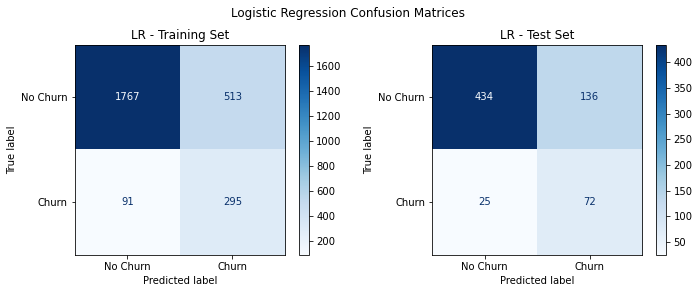

In [60]:


# Predictions
y_train_pred = lr.predict(X_train_sc)
y_test_pred = lr.predict(X_test_sc)

# Create confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Training set
disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=['No Churn', 'Churn']
)
disp_train.plot(cmap='Blues', ax=axes[0])
axes[0].set_title("LR - Training Set")

# Test set
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=['No Churn', 'Churn']
)
disp_test.plot(cmap='Blues', ax=axes[1])
axes[1].set_title("LR - Test Set")

plt.suptitle("Logistic Regression Confusion Matrices")
plt.tight_layout()
plt.show()

### Logistic Regression — Confusion Matrix Interpretation

**Test Set Results:**
- The model correctly identified **72 out of 97 churners** (74.2% recall)
- Only **25 churners were missed** — these are the costly false negatives
- **136 customers were falsely flagged** — acceptable trade-off since 
  retaining a non-churner costs less than losing an actual churner

**Conclusion:** A solid baseline. We now move to a nonparametric model 
(Decision Tree) to see if we can reduce missed churners further.

## 4.2 Model 2 — Decision Tree (Non-Parametric)

**Justification:** We move to a Decision Tree because:
- Logistic Regression assumes a **linear decision boundary** — 
  churn behavior may not be linear
- Decision trees are **nonparametric** — they make no assumptions 
  about feature distributions
- They can capture **nonlinear patterns** e.g. customers who call 
  support 4+ times churn at much higher rates
- They do **not require scaling** — making them easier to interpret
- We use `max_depth=5` to prevent overfitting

In [61]:
# Fit Decision Tree
# Decision trees don't require scaling, so we use unscaled data
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

print('=' * 50)
print('DECISION TREE')
print('=' * 50)

for label, X_eval, y_eval in [('TRAIN', X_train, y_train), ('TEST', X_test, y_test)]:
    preds = dt.predict(X_eval)
    print(f'\n--- {label} ---')
    print(classification_report(y_eval, preds, target_names=['No Churn', 'Churn']))
    print(f'Recall:  {recall_score(y_eval, preds):.3f}')
    proba = dt.predict_proba(X_eval)[:, 1]
    print(f'ROC-AUC: {roc_auc_score(y_eval, proba):.3f}')

DECISION TREE

--- TRAIN ---
              precision    recall  f1-score   support

    No Churn       0.98      0.96      0.97      2280
       Churn       0.79      0.85      0.82       386

    accuracy                           0.95      2666
   macro avg       0.88      0.91      0.90      2666
weighted avg       0.95      0.95      0.95      2666

Recall:  0.855
ROC-AUC: 0.931

--- TEST ---
              precision    recall  f1-score   support

    No Churn       0.95      0.94      0.94       570
       Churn       0.65      0.72      0.69        97

    accuracy                           0.90       667
   macro avg       0.80      0.83      0.81       667
weighted avg       0.91      0.90      0.91       667

Recall:  0.722
ROC-AUC: 0.803


### Decision Tree — Results Interpretation

**Key observations:**
- **Test Recall: 0.722** — identifies 72% of actual churners on unseen data
- **Overfit gap: 0.133** — train recall (0.855) is much higher than test 
  recall (0.722), showing the model memorizes training data more than 
  Logistic Regression did
- **ROC-AUC: 0.803** — slightly lower than Logistic Regression (0.828)

**Conclusion:** The Decision Tree performs worse than Logistic Regression 
on all key metrics and overfits more. We now explore Random Forest — an 
ensemble of trees — to see if combining many trees reduces overfitting.

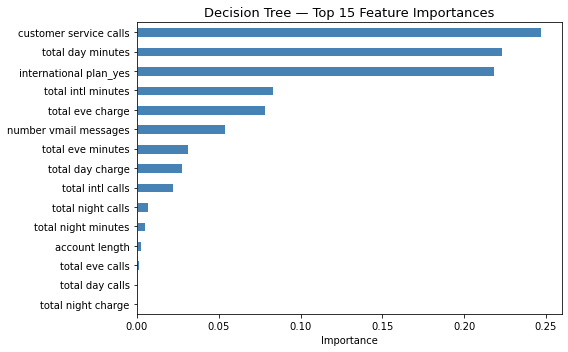

In [69]:
# Feature importance — Decision Tree
feat_imp = pd.Series(
    dt.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Decision Tree — Top 15 Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Decision Tree — Feature Importance Insight
The most important features identified by the Decision Tree are:
- **Total day charge / minutes** — high usage customers churn more
- **Customer service calls** — repeated calls signal dissatisfaction
- **International plan** — subscribers churn at higher rates

These insights directly inform our business recommendations.

## 4.3. Model 3 — Random Forest (Ensemble — Final Model)

The decision tree may overfit — a single tree is sensitive to the exact training data. Random Forest addresses this by:

- Training **many trees** on random subsets of data (bagging)
- Each tree considers only a **random subset of features** at each split
- Final prediction is the **majority vote** across all trees

This reduces variance significantly while retaining the ability to 
capture non-linear patterns. However, as we will see in the evaluation, 
Random Forest overfits more than expected — making Logistic Regression 
the stronger choice for this dataset.

In [70]:
# Fit Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)
rf.fit(X_train, y_train)

print('=' * 50)
print('RANDOM FOREST')
print('=' * 50)

for label, X_eval, y_eval in [('TRAIN', X_train, y_train), ('TEST', X_test, y_test)]:
    preds = rf.predict(X_eval)
    print(f'\n--- {label} ---')
    print(classification_report(y_eval, preds, target_names=['No Churn', 'Churn']))
    print(f'Recall:  {recall_score(y_eval, preds):.3f}')
    proba = rf.predict_proba(X_eval)[:, 1]
    print(f'ROC-AUC: {roc_auc_score(y_eval, proba):.3f}')

RANDOM FOREST

--- TRAIN ---
              precision    recall  f1-score   support

    No Churn       0.98      1.00      0.99      2280
       Churn       1.00      0.91      0.95       386

    accuracy                           0.99      2666
   macro avg       0.99      0.95      0.97      2666
weighted avg       0.99      0.99      0.99      2666

Recall:  0.909
ROC-AUC: 1.000

--- TEST ---
              precision    recall  f1-score   support

    No Churn       0.95      0.98      0.96       570
       Churn       0.83      0.70      0.76        97

    accuracy                           0.94       667
   macro avg       0.89      0.84      0.86       667
weighted avg       0.93      0.94      0.93       667

Recall:  0.701
ROC-AUC: 0.888


**Conclusion:** Despite being the most complex model, Random Forest 
performs worst on test recall (0.701) and has the largest overfit gap 
(0.208). Its perfect training ROC-AUC of 1.000 confirms it is 
memorizing training data rather than learning generalizable patterns.

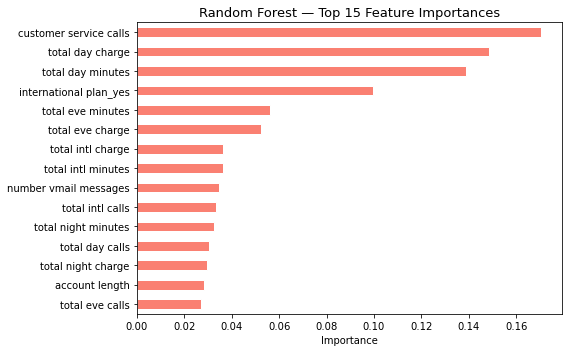

In [71]:
# Feature importance — Random Forest
rf_imp = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
rf_imp.plot(kind='barh', color='salmon', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Random Forest — Top 15 Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Random Forest — Feature Importance Insight
The most important features identified by the Random Forest are:

1. **Customer service calls** — #1 in both models. Strongest churn signal.
2. **Total day charge / minutes** — high usage = price sensitivity
3. **International plan** — subscribers churn at higher rates

Both the Decision Tree and Random Forest agree on the top churn drivers. This gives us confidence that these are genuinely important predictors.

## 5. Evaluation

### 5.1 Model Comparison

We evaluate all three models using the same metrics for a fair comparison.
Our primary metric is **Recall** — We are keen on minimizing missed churners.

In [76]:
# Summary comparison table
results = []

models = [
    ('Logistic Regression', lr, X_train_sc, X_test_sc),
    ('Decision Tree',       dt, X_train,    X_test),
    ('Random Forest',       rf, X_train,    X_test),
]

for name, model, X_tr, X_te in models:
    train_preds = model.predict(X_tr)
    test_preds  = model.predict(X_te)
    test_proba  = model.predict_proba(X_te)[:, 1]
    
    results.append({
        'Model':         name,
        'Train Recall':  round(recall_score(y_train, train_preds), 3),
        'Test Recall':   round(recall_score(y_test,  test_preds),  3),
        'Test ROC-AUC':  round(roc_auc_score(y_test, test_proba),  3),
        'Overfit Gap':   round(recall_score(y_train, train_preds) -
                               recall_score(y_test,  test_preds),  3)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Recall,Test Recall,Test ROC-AUC,Overfit Gap
Model,,,,
Logistic Regression,0.764,0.742,0.815,0.022
Decision Tree,0.855,0.722,0.803,0.133
Random Forest,0.909,0.701,0.888,0.208


### 5.2 Results Interpretation

- **Logistic Regression** wins on test recall (0.742) and has the 
  lowest overfit gap (0.022) — most reliable for new customers
- **Decision Tree** overfits moderately (gap = 0.133)
- **Random Forest** overfits heavily (gap = 0.208) despite highest 
  training recall (0.909)

**Selected Model: Logistic Regression**

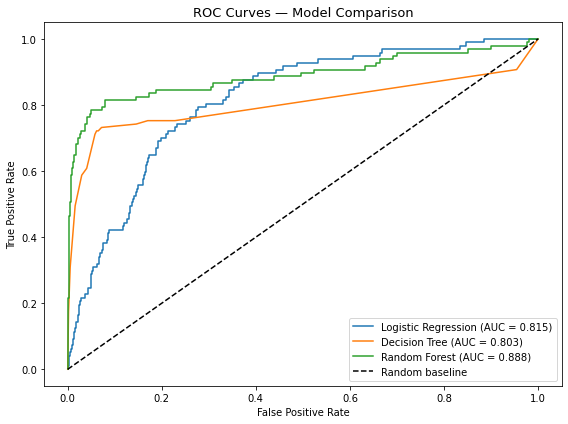

In [78]:
# ROC curves — all three models

fig, ax = plt.subplots(figsize=(8, 6))

for name, model, _, X_te in models:
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.3 ROC Curve Interpretation
**Key observations:**
- **Random Forest (AUC = 0.888)** — best overall discrimination 
  ability but overfits heavily on training data
- **Logistic Regression (AUC = 0.815)** — strong discrimination 
  with the most consistent generalization
- **Decision Tree (AUC = 0.803)** — lowest AUC, most erratic curve
- All three models are well above the **random baseline (dashed line)** 
  confirming all are genuinely predictive
  
  Logistic Regression's test recall (0.742) outperforms both other models.